In [1]:
import pandas as pd 
import numpy as np

#### EarlyStopping

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [10]:
x, y = make_circles(n_samples=100, noise=0.1, random_state=1)

In [11]:
x

array([[-0.63640493, -0.36870191],
       [-0.24465976, -0.73659196],
       [-0.46597138, -1.06687743],
       [-0.70999784, -0.40841948],
       [ 0.70232238, -0.51730147],
       [-0.49776571,  0.76955129],
       [-0.31914906, -0.84899624],
       [-0.57839322, -0.49081236],
       [-0.53350227,  0.58056527],
       [-0.24733259,  0.73011595],
       [ 0.41030774, -0.73075986],
       [ 0.17181003, -0.92504802],
       [ 0.65917045,  0.62120588],
       [ 0.87625577,  0.12510879],
       [ 0.81946243, -0.01347859],
       [-0.47960986, -0.7880243 ],
       [-0.90187751, -0.70895455],
       [ 0.74827659, -0.55976747],
       [-0.74875324, -0.37153443],
       [ 0.23161178,  1.01205842],
       [ 0.81387506,  0.22821311],
       [-0.92169575,  0.20310719],
       [ 0.74650434, -0.35861224],
       [ 0.01330079,  0.68169193],
       [-0.72651409,  0.58630948],
       [-0.33930852, -1.0080984 ],
       [ 0.49009938, -0.62509577],
       [-0.9539309 , -0.33410313],
       [ 0.6927241 ,

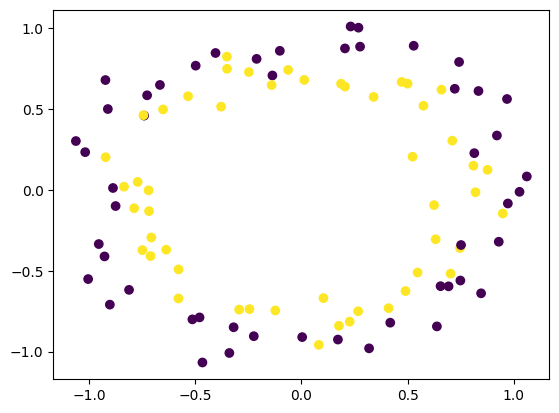

In [18]:


# Assuming y is numeric or can be mapped to numeric values
plt.scatter(x[:, 0], x[:, 1], c=y)  # Or any other colormap
plt.show()


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2)

In [20]:
model = Sequential()
model.add(Dense(256, input_dim = 2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(loss ='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [24]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5195 - loss: 0.6942 - val_accuracy: 0.4500 - val_loss: 0.6962
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5039 - loss: 0.6948 - val_accuracy: 0.5500 - val_loss: 0.6950
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5773 - loss: 0.6919 - val_accuracy: 0.5500 - val_loss: 0.6935
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5023 - loss: 0.6929 - val_accuracy: 0.5500 - val_loss: 0.6931
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5180 - loss: 0.6918 - val_accuracy: 0.5500 - val_loss: 0.6927
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5813 - loss: 0.6914 - val_accuracy: 0.5500 - val_loss: 0.6925
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6961 - loss: 0.6896 - val_accuracy: 0.6000 - val_loss: 0.6924
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6766 - loss: 0.6900 - val_accuracy: 0.6500 - v

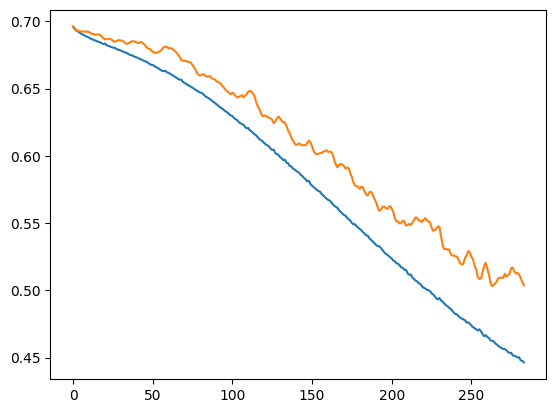

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])